# step 1 notes
## Creation of Synthetic Neural Responses and MEI extraction

### Synthetic Neural Responses

Synthetic neural responses are idealised firing (FR) rates in response to a patch ("receptive field") of an image taken from a dataset such as cifar10 or mnist. The patch is choosen randomly. The FR is calculated starting from the dot product between the patch and a "response filter", i.e. the preferred 2D stimulus pattern for the idealised neuron. This 2D pattern is aclled metaphorically STA in the code and can be made from periodic patterns, perlin noise, random noise, or a CNN activation.
The combination that I am now preferring is periodic patterns with 70x70 patches of cifa10 dataset.
The dot product is then modified including a baseline, an upper threshold and an adaptation factor. (can be removed for simplicity)

In [3]:
# Load generated datasets
from pathlib import Path

path_to_main_folder = Path("/ceph/margrie/laura/neurodecoders")
path_to_workspace = path_to_main_folder / "workspace"
path_to_synthetic_data = path_to_workspace / "datasets" / "synthetic"

datasets = list(path_to_synthetic_data.glob("*.npz"))
for dataset in datasets:
    print(dataset.name)

synthdata_dataset-cifar10_sta-periodic_patterns,70,70_n_neurons-10_n_images-10_datetime-20250813_165545.npz
synthdata_dataset-cifar10_sta-periodic_patterns,70,70_n_neurons-100_n_images-10000_datetime-20250812_153359.npz


In [4]:
# let's look at the small dataset and see what there is inside
import numpy as np

small_dataset_path = datasets[0]
data = np.load(small_dataset_path)
data.files

['images',
 'responses',
 'stas',
 'rf_coords',
 'adaptation_states',
 'labels',
 'sta_avg_correlations']

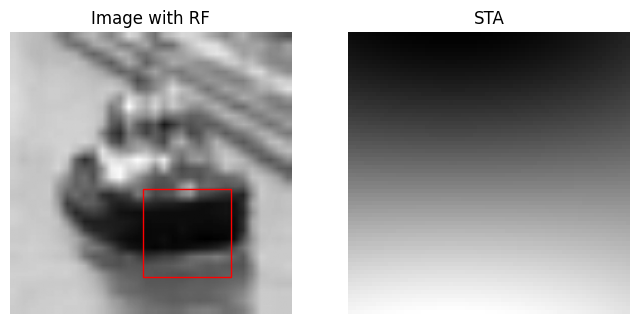

Firing rate for the first neuron and first image: 51.82 Hz


In [36]:
# Let's plot one example of image and STA and also a bounding box of the 70x70 RF
import matplotlib.pyplot as plt

image = data["images"][0][0, :, :]  # first image, first channel
sta = data["stas"][0]
rf_coords = data["rf_coords"][0]

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(image, cmap="gray")
rect = plt.Rectangle(
    (rf_coords[0], rf_coords[1]), 70, 70, linewidth=1, edgecolor="r", facecolor="none"
)
ax[0].add_patch(rect)   
ax[0].set_title("Image with RF")
ax[1].imshow(sta, cmap="gray")
ax[1].set_title("STA")
ax[0].axis("off")
ax[1].axis("off")
plt.show()

#  let's also print the firing rate for this neuron and this image
firing_rate = data["responses"][0][0]  # first neuron, first image
print(f"Firing rate for the first neuron and first image: {firing_rate:.2f} Hz")

Creating z-score normalized average images for 1 neurons...


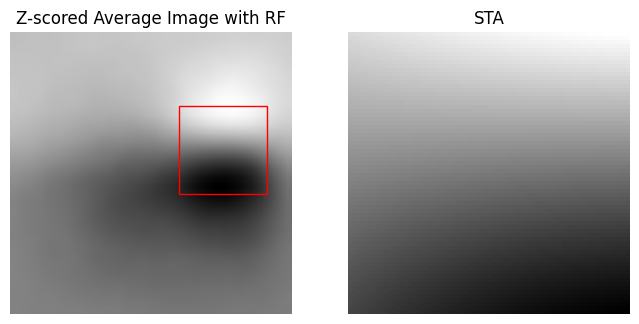

In [33]:
# let's look at the big dataset and create z-scored neuron average images 
# to see if they look like the STA
from neurodecoders.synthetic.create_zscored_neuron_averages import (
    create_zscore_neuron_average_images,
)

big_dataset_path = datasets[1]
big_data = np.load(big_dataset_path)

average_images_zscore = create_zscore_neuron_average_images(
        big_data["images"], big_data["responses"], n_neurons=1
    )

#  plot the z-scored average image and the patch bounding box
sta = big_data["stas"][0]
rf_coords = big_data["rf_coords"][0]
zscore_image = average_images_zscore[0][0, :, :]  
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(zscore_image, cmap="gray")
rect = plt.Rectangle(
    (rf_coords[0], rf_coords[1]), 70, 70, linewidth=1, edgecolor="r", facecolor="none"
)
ax[0].add_patch(rect)
ax[0].set_title("Z-scored Average Image with RF")
ax[1].imshow(sta, cmap="gray")
ax[1].set_title("STA")
ax[0].axis("off")
ax[1].axis("off")
plt.show()
